# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [24]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Amir Goyri"            # Tu nombre completo
MATRICULA = "81737"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "pib"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Amir Goyri
Matrícula: 81737
Dataset asignado: pib


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [25]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


/Users/amirgoyriespinoza/Desktop/Lasalle/5to/Big Data/.venv/bin/python


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: pib
Descripcion: PIB per capita (dolares constantes de 2015) (USD)


In [27]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [28]:
df.head(50)

,entity,code,year,valor
0,Afghanistan,AFG,2000,308.31827
1,Afghanistan,AFG,2001,277.11804
2,Afghanistan,AFG,2002,338.13998
3,Afghanistan,AFG,2003,346.07162
4,Afghanistan,AFG,2004,338.63727
5,Afghanistan,AFG,2005,363.64014
6,Afghanistan,AFG,2006,367.75830
7,Afghanistan,AFG,2007,410.75772
8,Afghanistan,AFG,2008,417.64728
9,Afghanistan,AFG,2009,488.83066


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [29]:
# Forma del dataset (filas, columnas)
df.shape


(12384, 4)

In [30]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12384 entries, 0 to 12383
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  12384 non-null  str    
 1   code    12384 non-null  str    
 2   year    12384 non-null  int64  
 3   valor   12384 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 387.1 KB


In [31]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count     12384.000000
mean      12434.415310
std       19221.293985
min         122.678900
25%        1370.694600
50%        4089.543600
75%       16127.642000
max      247170.110000
Name: valor, dtype: float64

In [32]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity    0
code      0
year      0
valor     0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

Puedo observar que no existen valores nulos ya que se trabaja con el pib y el pib de un país no puede ser nulo. Se maneja un rango de años bastante amplio, del año 2000 al 2024 y esto me imagino que puede ser para hacer analisis profundos de crecimiento, ya que si se usara un rango de digamos 5 años, se observarían datos anomalos, como podría ser una caída del pib per capita en años de covid, durante estos años la economía de la mayoría de paises sufrió bastante.

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [33]:
df_paises = df[df[config["filtro_paises"]].notnull()]
n_paises = df_paises["entity"].nunique()
print("paises distintos:", n_paises)
anio_reciente = df_paises["year"].max()
print("Anio mas reciente disponible:", anio_reciente)

df_anio = df_paises[df_paises["year"] == anio_reciente]

top10_mayor = df_anio.sort_values("valor", ascending=False).head(10)
print("Top 10 paises con mayor valor:")
print(top10_mayor[["entity", "valor"]])

top10_menor = df_anio.sort_values("valor", ascending=True).head(10)
print("Top 10 paises con menor valor:")
print(top10_menor[["entity", "valor"]])

paises distintos: 226
Anio mas reciente disponible: 2025
Top 10 paises con mayor valor:
                   entity       valor
5397              Ireland  104416.836
6624           Luxembourg  103292.150
10882         Switzerland   93327.590
8437               Norway   83812.760
10014           Singapore   70683.680
11809       United States   67945.620
6668                Macao   66444.080
8314   North America (WB)   65507.547
2861              Denmark   62217.610
9211                Qatar   61734.690
Top 10 paises con menor valor:
                             entity      valor
1689                        Burundi  273.43298
2003       Central African Republic  393.98830
6734                     Madagascar  456.50967
10215                       Somalia  465.43940
6800                         Malawi  548.16046
2795   Democratic Republic of Congo  567.56030
10684                         Sudan  582.11410
7683                     Mozambique  585.68260
8182                          Niger  610

**Interpretación:**

Podemos interpretar que los paises con mayor pib son principalmente paises europeos, mientras que los que tiene menor pib son africanos 

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [34]:
pais1 = "Mexico"
pais2 = "Japan"

mexico = df_paises[df_paises["entity"] == pais1]
japon = df_paises[df_paises["entity"] == pais2]

anio_inicio = max(mexico["year"].min(), japon["year"].min())
anio_fin = min(mexico["year"].max(), japon["year"].max())
print("Rango de anios disponible para ambos:", anio_inicio, "-", anio_fin)

df_dos_paises = df_paises[
    (df_paises["entity"].isin([pais1, pais2])) &
    (df_paises["year"] >= anio_inicio) &
    (df_paises["year"] <= anio_fin)
]
print(df_dos_paises)

Rango de anios disponible para ambos: 1960 - 2025
      entity code  year       valor
5630   Japan  JPN  1960   6481.3745
5631   Japan  JPN  1961   7197.1820
5632   Japan  JPN  1962   7765.8830
5633   Japan  JPN  1963   8338.9940
5634   Japan  JPN  1964   9216.3220
...      ...  ...   ...         ...
7286  Mexico  MEX  2021   9728.0570
7287  Mexico  MEX  2022  10013.2480
7288  Mexico  MEX  2023  10234.6840
7289  Mexico  MEX  2024  10284.0340
7290  Mexico  MEX  2025  10256.6870

[132 rows x 4 columns]


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [35]:
paises_mundialistas = ["Mexico", "Brazil", "Germany", "Morocco", "Japan"]

anio_reciente = df_paises["year"].max()
print("Anio mas reciente disponible:", anio_reciente)

df_comparacion = df_paises[(df_paises["entity"].isin(paises_mundialistas)) & (df_paises["year"] == anio_reciente)]
print(df_comparacion[["entity", "valor"]])

valor_max = df_comparacion["valor"].max()
valor_min = df_comparacion["valor"].min()

print("Pais con valor mas alto:")
print(df_comparacion[df_comparacion["valor"] == valor_max])

print("Pais con valor mas bajo:")
print(df_comparacion[df_comparacion["valor"] == valor_min])

diferencia = valor_max - valor_min
print("Diferencia entre ambos:", diferencia)

Anio mas reciente disponible: 2025
       entity       valor
1459   Brazil   9747.9950
4172  Germany  44146.6400
5695    Japan  38619.3360
7290   Mexico  10256.6870
7637  Morocco   3643.8096
Pais con valor mas alto:
       entity code  year     valor
4172  Germany  DEU  2025  44146.64
Pais con valor mas bajo:
       entity code  year      valor
7637  Morocco  MAR  2025  3643.8096
Diferencia entre ambos: 40502.8304


**Interpretación:**

Como comentamos en la interpretación anterior, el país con el pib más alto, fue el país europeo y el que tuvo el más bajo fue el país africano

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [36]:
latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]

anio_reciente = df_paises["year"].max()
print("Anio mas reciente disponible:", anio_reciente)

df_latam = df_paises[(df_paises["entity"].isin(latinoamerica)) & (df_paises["year"] == anio_reciente)]
df_asia = df_paises[(df_paises["entity"].isin(asia)) & (df_paises["year"] == anio_reciente)]

print(df_latam[["entity", "valor"]])
print(df_asia[["entity", "valor"]])

promedio_latam = df_latam["valor"].mean()
promedio_asia = df_asia["valor"].mean()

print("Promedio Latinoamerica:", promedio_latam)
print("Promedio Asia:", promedio_asia)

Anio mas reciente disponible: 2025
         entity      valor
374   Argentina  13287.116
2282   Colombia   6975.567
7290     Mexico  10256.687
        entity      valor
2216     China  13793.206
5695     Japan  38619.336
12156  Vietnam   4308.205
Promedio Latinoamerica: 10173.123333333335
Promedio Asia: 18906.915666666668


**Interpretación:**

Con la muestra tomada, podemos decir que en promedio, Asia tiene mejor pib per capita que LatinoAmerica

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [37]:
pais = "United States"

df_pais = df_paises[df_paises["entity"] == pais]
print(df_pais[["year", "valor"]])

valor_max = df_pais["valor"].max()
valor_min = df_pais["valor"].min()

print("Valor maximo:")
print(df_pais[df_pais["valor"] == valor_max])

print("Valor minimo:")
print(df_pais[df_pais["valor"] == valor_min])

       year      valor
11744  1960  18991.545
11745  1961  19108.936
11746  1962  19965.145
11747  1963  20545.785
11748  1964  21437.584
...     ...        ...
11805  2021  63096.785
11806  2022  64322.234
11807  2023  65667.280
11808  2024  66856.516
11809  2025  67945.620

[66 rows x 2 columns]
Valor maximo:
              entity code  year     valor
11809  United States  USA  2025  67945.62
Valor minimo:
              entity code  year      valor
11744  United States  USA  1960  18991.545


**Interpretación:**

Podemos notar un gran crecimiento de casi el 200% en el pib per capita de estados unidos. Esto significa tendencia general creaciente pero que ha llegado a caer en las crisis económicas más importantes, como puede ser la pandemia

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [38]:
df_pais_ordenado = df_pais.sort_values("year")

primer_anio = df_pais_ordenado["year"].iloc[0]
ultimo_anio = df_pais_ordenado["year"].iloc[-1]

valor_primero = df_pais_ordenado["valor"].iloc[0]
valor_ultimo = df_pais_ordenado["valor"].iloc[-1]

print("Primer anio:", primer_anio, "Valor:", valor_primero)
print("Ultimo anio:", ultimo_anio, "Valor:", valor_ultimo)

cambio_porcentual = (valor_ultimo - valor_primero) / valor_primero * 100
print("Cambio porcentual:", cambio_porcentual)

Primer anio: 1960 Valor: 18991.545
Ultimo anio: 2025 Valor: 67945.62
Cambio porcentual: 257.76773295695534


**Interpretación:**

El pib per capita de mexico subió bastante entre 1960 y 2025, casi se duplicó (+147%). Creo que esto se debe al crecimiento economico del país a lo largo de tantos años y a cosas como el TLCAN que ayudaron a las exportaciones, aunque seguro en el camino hubo caidas fuertes por crisis como la de 1994 o la pandemia, solo que al ver nada más el primer y el ultimo año esas bajadas no se notan.


### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [39]:
anio_reciente = df_paises["year"].max()
df_anio = df_paises[df_paises["year"] == anio_reciente]

valores = df_anio["valor"].dropna().to_numpy()

media = np.mean(valores)
mediana = np.median(valores)
desviacion = np.std(valores)

print("Media:", media)
print("Mediana:", mediana)
print("Desviacion estandar:", desviacion)

Media: 15459.015913467334
Mediana: 6782.7505
Desviacion estandar: 20190.97388314071


**Interpretación:**

La media es más del doble que la mediana, lo cual indica que la distribución del pib per capita no es simétrica: existe un grupo reducido de países con valores muy altos (economías desarrolladas) que eleva el promedio, mientras que la mayoría de los países se ubica en un nivel mucho más bajo, cercano a la mediana. La desviación estándar también es bastante grande, incluso mayor que la propia media, lo que confirma que existe una desigualdad económica considerable entre los países del mundo.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

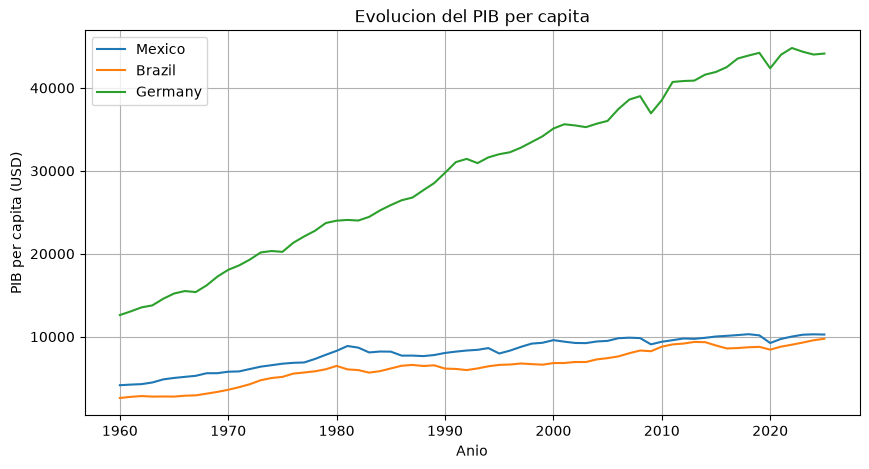

In [40]:
pais1 = "Mexico"
pais2 = "Brazil"
pais3 = "Germany"

df_pais1 = df_paises[df_paises["entity"] == pais1]
df_pais2 = df_paises[df_paises["entity"] == pais2]
df_pais3 = df_paises[df_paises["entity"] == pais3]

anios_pais1 = df_pais1["year"].to_numpy()
valores_pais1 = df_pais1["valor"].to_numpy()

anios_pais2 = df_pais2["year"].to_numpy()
valores_pais2 = df_pais2["valor"].to_numpy()

anios_pais3 = df_pais3["year"].to_numpy()
valores_pais3 = df_pais3["valor"].to_numpy()

plt.figure(figsize=(10, 5))

plt.plot(anios_pais1, valores_pais1, label=pais1)
plt.plot(anios_pais2, valores_pais2, label=pais2)
plt.plot(anios_pais3, valores_pais3, label=pais3)

plt.title("Evolucion del PIB per capita")
plt.xlabel("Anio")
plt.ylabel(f"PIB per capita ({config['unidad']})")
plt.legend()
plt.grid(True)
plt.show()


**Interpretación:**

Se observa que Alemania mantiene un pib per capita considerablemente más alto que México y Brasil durante todo el periodo, aunque su crecimiento es más moderado en términos relativos. México y Brasil parten de niveles similares y más bajos en 1960, pero muestran un crecimiento más marcado en las últimas décadas, con Brasil acercándose al nivel de México hacia el final del periodo. En los tres países se aprecian caídas puntuales que coinciden con crisis económicas globales, aunque la tendencia general de largo plazo es de crecimiento.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

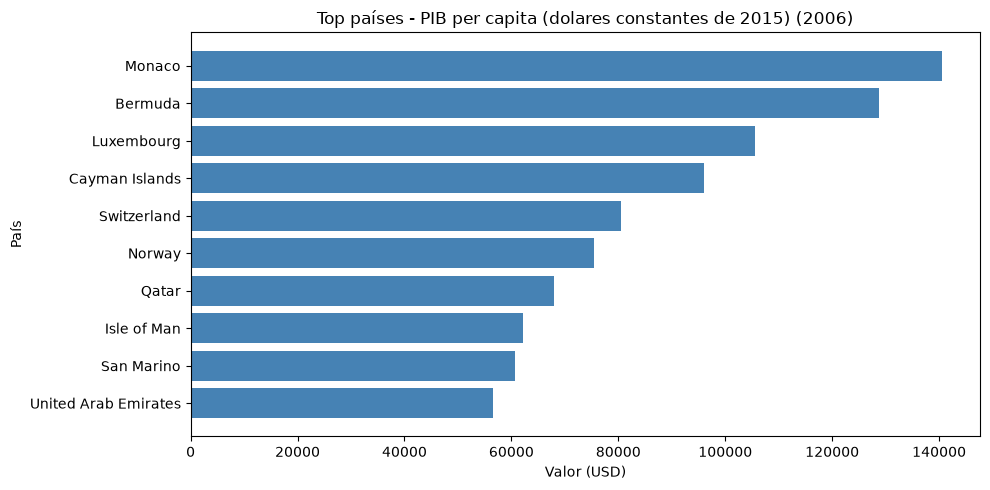

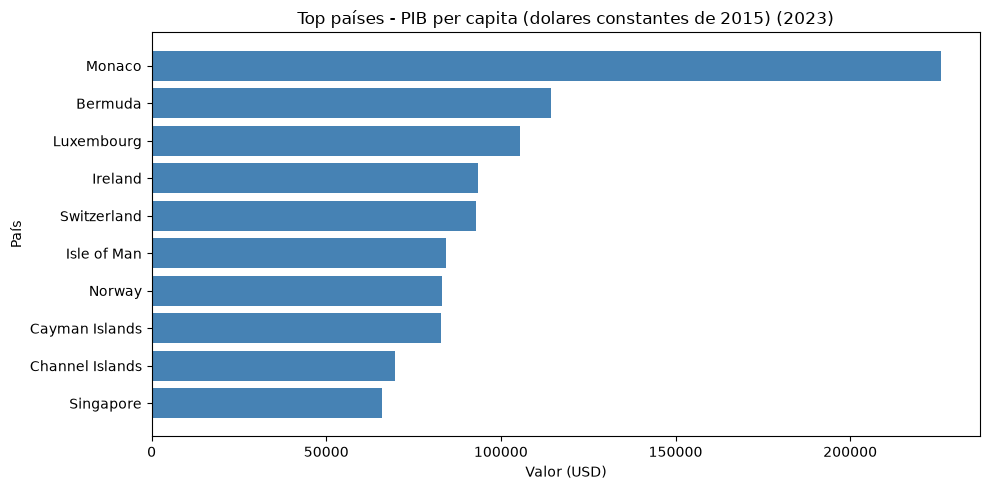

In [41]:
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_consultado = 2006

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()

anio_consultado_2023 = 2023

top_2023 = (
    df_paises[df_paises['year'] == anio_consultado_2023]
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_2023['entity'], top_2023['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado_2023})")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Interpretación:**

Al comparar ambas gráficas se observa que los primeros tres lugares se mantienen iguales en ambos años (Mónaco, Bermuda y Luxemburgo), aunque no todos crecen de la misma forma: Mónaco aumenta considerablemente su pib per capita, mientras que Bermuda incluso lo reduce ligeramente. También destaca la salida de Qatar, San Marino y Emiratos Árabes Unidos del top 10 hacia 2023, siendo reemplazados por países como Irlanda, Singapur y las Islas del Canal. Esto sugiere que, si bien el grupo de países más ricos del mundo es relativamente estable en su núcleo, sí hay movimiento entre los últimos lugares del top 10, y que economías pequeñas o centros financieros específicos tienden a dominar este ranking más que las grandes potencias económicas tradicionales.

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Este dataset permitió ver de forma más clara las diferencias económicas entre países a lo largo del tiempo. Uno de los patrones más claros es que la distribución del pib per capita está muy sesgada: la mayoría de los países se concentra en valores relativamente bajos, mientras que un grupo reducido (principalmente economías pequeñas o centros financieros como Mónaco, Bermuda o Luxemburgo) domina la parte alta del ranking, muy por encima de las grandes potencias económicas tradicionales.

También pude notar que, aunque el crecimiento de largo plazo es generalmente positivo para la mayoría de los países analizados, existen caídas puntuales asociadas a crisis económicas específicas, lo cual demuestra que el crecimiento no es un proceso lineal. Entre las limitaciones del dataset, destaca que al estar expresado en dólares constantes 
, no se toma en cuenta el costo de vida  en cada país, y al ser un promedio por habitante tampoco muestra qué tan desigual es la distribución del ingreso dentro de cada país.

Si tuviera más tiempo, me interesaría complementar este análisis con datos de costo de vida en un país tomando un indicador importante como el costo de la vivienda, así como con algún indicador de desigualdad interna, para tener una visión más completa del bienestar económico de cada país y no solo de su tamaño económico promedio.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
